In [69]:
import json
import requests
import shutil
import pandas as pd
import os
import gtfs_realtime_pb2
from datetime import datetime
from collections import deque
import _utils_ as utils
import metrics

import logging
# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)


In [41]:
from google.protobuf.json_format import MessageToDict, MessageToJson
import google.protobuf
print(google.protobuf.__version__)

6.33.4


## 1 - Descargar informacion estatica del sistema




In [42]:
# Configuration
gtfs_static_dirs = {
    "durham":{
        "path":"GTFS_static/GTFS_Durham_TXT",
        "last_retrieved": "2026-02-16"
    }, 
    "montreal":{
        "path":"GTFS_static/GTFS_Montreal_TXT",
        "last_retrieved": "2026-06-15"
    }
}

In [43]:
gtfs_rt_urls = {
    'durham': {
        'vehicle_positions_url': 'https://drtonline.durhamregiontransit.com/gtfsrealtime/VehiclePositions',
        'trip_updates_url': 'https://drtonline.durhamregiontransit.com/gtfsrealtime/TripUpdates',
        'headers': {
            'accept': 'application/x-protobuf'
            },
        'format': 'protobuf',
        'main_route_id': '905',
        'max_position_history': 3},

    'montreal': {
        'vehicle_positions_url': 'https://api.stm.info/pub/od/gtfs-rt/ic/v2/vehiclePositions',
        'trip_updates_url':      'https://api.stm.info/pub/od/gtfs-rt/ic/v2/tripUpdates',
        'headers': {
            'apiKey': os.getenv('STM_API_KEY'),
            'accept': 'application/x-protobuf',
            'max_position_history': 3
            },
        'format': 'protobuf',
        'main_route_id': '1',
        'max_position_history': 3
        },
}

Explorar las columnas y tipos de datos

In [54]:
city = "durham"  # Change to "montreal" for Montreal data
routes = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "routes.txt"))
print("Dimensiones de datos (filas,columnas)", routes.shape)
routes.head()

Dimensiones de datos (filas,columnas) (39, 9)


,route_long_name,route_type,route_text_color,route_color,route_url,agency_id,route_short_name,route_id,route_desc
0,Route 101,3,ffffff,006633,NaN,drt,101,101,NaN
1,Route 112,3,ffffff,006633,NaN,drt,112,112,NaN
2,Route 118,3,ffffff,006633,NaN,drt,118,118,NaN
3,Route 121,3,ffffff,006633,NaN,drt,121,121,NaN
4,Route 211,3,ffffff,006633,NaN,drt,211,211,NaN


In [55]:
shapes = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "shapes.txt"))
print(shapes.shape)
shapes_layer = utils.df_to_geojson(shapes, "shape_pt_lat", "shape_pt_lon", geometry_type="LineString", output_file="geojson_layers/shapes.geojson", group_by="shape_id")
shapes.head()

(213045, 5)


,shape_id,shape_pt_lat,shape_pt_lon,shape_pt_sequence,shape_dist_traveled
0,100.0.1952648908_Timetable_-_2026-01,43.832720,-79.085610,1,0.000000
1,100.0.1952648908_Timetable_-_2026-01,43.832654,-79.085581,2,7.707915
2,100.0.1952648908_Timetable_-_2026-01,43.832645,-79.085601,3,9.625517
3,100.0.1952648908_Timetable_-_2026-01,43.832590,-79.085735,4,21.991927
4,100.0.1952648908_Timetable_-_2026-01,43.832550,-79.085855,5,32.595411


In [56]:
stops = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "stops.txt"))
print(stops.shape)
utils.df_to_geojson(stops, "stop_lat", "stop_lon", geometry_type="Point", output_file="geojson_layers/stops.geojson", group_by=None)
print(type(stops['stop_id'].iloc[0]))
stops.head(4)

(1909, 13)
<class 'str'>


,stop_desc,stop_url,stop_name,stop_lat,stop_code,stop_id,location_type,preferred,stop_timezone,stop_lon,parent_station,zone_id,wheelchair_boarding
0,NaN,NaN,Garden Northbound @ Bassett (South stop),43.903333,10,10,0,2,NaN,-78.941559,NaN,NaN,1
1,NaN,NaN,McQuay Northbound @ Dundas,43.875932,100,100,0,2,NaN,-78.961715,NaN,NaN,1
2,NaN,NaN,Glen Northbound @ Medina,43.872683,1000,1000,0,2,NaN,-78.855412,NaN,NaN,1
3,NaN,NaN,Northbound @ 825 Glen,43.875296,1001,1001,0,2,NaN,-78.856489,NaN,NaN,1


In [57]:
trips = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "trips.txt"))
print(trips.shape)
trips.head(3)

(9557, 9)


,direction_name,wheelchair_accessible,block_id,trip_id,direction_id,shape_id,route_id,service_id,trip_headsign
0,Southbound,1,a_401047_Timetable_-_2026-01,1000__401047_Timetable_-_2026-01,1,100.0.2273959138_Timetable_-_2026-01,901,Weekday_merged_94404,A - Lakeview Park
1,Southbound,1,a_401002_Timetable_-_2026-01,1001__401002_Timetable_-_2026-01,1,100.0.2273959138_Timetable_-_2026-01,901,Weekday_merged_94404,A - Lakeview Park
2,Southbound,1,a_401028_Timetable_-_2026-01,1002__401028_Timetable_-_2026-01,1,100.0.2273959138_Timetable_-_2026-01,901,Weekday_merged_94404,A - Lakeview Park


In [58]:
stop_times = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "stop_times.txt"))
print(stop_times.shape)
stop_times.head()

(383537, 10)


/var/folders/d4/n09rk8xd7k72h1ksgf14nmkr0000gn/T/ipykernel_47035/2541779889.py:1: DtypeWarning: Columns (0: stop_id) have mixed types. Specify dtype option on import or set low_memory=False.
  stop_times = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "stop_times.txt"))


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint
0,1000__401047_Timetable_-_2026-01,12:40:00,12:40:00,698,1,NaN,NaN,NaN,NaN,1.0
1,1000__401047_Timetable_-_2026-01,12:41:25,12:41:25,94189,2,NaN,NaN,NaN,NaN,NaN
2,1000__401047_Timetable_-_2026-01,12:42:25,12:42:25,706,3,NaN,NaN,NaN,NaN,NaN
3,1000__401047_Timetable_-_2026-01,12:43:25,12:43:25,707,4,NaN,NaN,NaN,NaN,NaN
4,1000__401047_Timetable_-_2026-01,12:45:51,12:45:51,710,5,NaN,NaN,NaN,NaN,NaN


## 2 - Union: Ejemplo con Paradas y Tiempos de Parada

In [59]:
print(stop_times.shape, stops.shape)
stops['stop_id'] = stops['stop_id'].astype(str)
stop_times['stop_id'] = stop_times['stop_id'].astype(str)
stops_times_merged = pd.merge(stop_times, stops, on='stop_id')
print("Dimensiones de tabla unida", stops_times_merged.shape)
stops_times_merged.head(3)

(383537, 10) (1909, 13)
Dimensiones de tabla unida (383537, 22)


,trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,shape_dist_traveled,timepoint,...,stop_name,stop_lat,stop_code,location_type,preferred,stop_timezone,stop_lon,parent_station,zone_id,wheelchair_boarding
0,1000__401047_Timetable_-_2026-01,12:40:00,12:40:00,698,1,NaN,NaN,NaN,NaN,1.0,...,Ontario Tech / Durham College North Campus,43.943641,698,0,1,NaN,-78.895505,NaN,NaN,1
1,1000__401047_Timetable_-_2026-01,12:41:25,12:41:25,94189,2,NaN,NaN,NaN,NaN,NaN,...,Simcoe Southbound @ Commencement,43.945083,94189,0,2,NaN,-78.892198,NaN,NaN,1
2,1000__401047_Timetable_-_2026-01,12:42:25,12:42:25,706,3,NaN,NaN,NaN,NaN,NaN,...,Simcoe Southbound @ Niagara (North stop),43.943084,706,0,2,NaN,-78.889191,NaN,NaN,1


In [60]:
#Fetch trip updates
#logger.info("Fetching trip updates...")
#trip_updates_feed = utils.fetch_gtfs_rt_feed(TRIP_UPDATES_URL)

## 3 - Información Dinámica con GET request


In [61]:
# Fetch vehicle positions
response = requests.get(gtfs_rt_urls[city]['vehicle_positions_url'], headers=gtfs_rt_urls[city]['headers'])
feed = gtfs_realtime_pb2.FeedMessage()
feed.ParseFromString(response.content)

print("Total records", len(feed.entity))
for entity in feed.entity[0:2]:
    if entity.HasField('vehicle'):
        vehicle = entity.vehicle
        position = vehicle.position
        print(f"Vehicle ID: {vehicle.vehicle.id}, Lat: {position.latitude}, Lon: {position.longitude}")

# Add timestamp to data
capture_timestamp = datetime.now()
veh_pos_dict = utils.get_veh_positions_dict(feed.entity, capture_timestamp)
veh_pos_df = pd.DataFrame(veh_pos_dict)
veh_pos_df.head()

Total records 125
Vehicle ID: 6100, Lat: 43.83821487426758, Lon: -79.08698272705078
Vehicle ID: 6101, Lat: 43.83293151855469, Lon: -79.08513641357422


,vehicle_id,bearing,speed,longitude,latitude,capture_timestamp,trip_id,route_id,direction_id,position_timestamp
0,6100,None,None,-79.086983,43.838215,2026-06-19T08:54:33.926628,1276__201059_Timetable_-_2026-04,211,None,2026-06-19T08:53:40
1,6101,None,None,-79.085136,43.832932,2026-06-19T08:54:33.926628,5600__201036_Timetable_-_2026-04,916,None,2026-06-19T08:54:16
2,6103,None,None,-78.854500,43.870232,2026-06-19T08:54:33.926628,5__401029_Timetable_-_2026-04,403,None,2026-06-19T08:53:58
3,6104,None,None,-79.038696,43.858383,2026-06-19T08:54:33.926628,1436__201087_Timetable_-_2026-04,920,None,2026-06-19T08:53:56
4,6109,None,None,-78.881401,43.874367,2026-06-19T08:54:33.926628,1049__401075_Timetable_-_2026-04,421,None,2026-06-19T08:54:08


In [62]:
# Fetch trip updates
response_tu = requests.get(gtfs_rt_urls[city]['trip_updates_url'], headers=gtfs_rt_urls[city]['headers'])
trip_updates_feed = gtfs_realtime_pb2.FeedMessage()
trip_updates_feed.ParseFromString(response_tu.content)

trip_updates_dict = utils.get_trip_updates_dict(trip_updates_feed.entity, capture_timestamp)
trip_updates_df = pd.DataFrame(trip_updates_dict)
print(f"Trip updates: {len(trip_updates_df)}")
trip_updates_df.head(3)


Trip updates: 7775


,entity_id,trip_id,route_id,direction_id,capture_timestamp,vehicle_id,stop_id,stop_sequence,arrival_delay,arrival_time,departure_delay,departure_time
0,2224__201004_Timetable_-_2026-04,2224__201004_Timetable_-_2026-04,118,None,2026-06-19T08:54:33.926628,6125,93580,1,None,2026-06-19T08:57:41,None,2026-06-19T08:57:41
1,2224__201004_Timetable_-_2026-04,2224__201004_Timetable_-_2026-04,118,None,2026-06-19T08:54:33.926628,6125,93582,2,None,2026-06-19T08:58:29,None,2026-06-19T08:58:29
2,2224__201004_Timetable_-_2026-04,2224__201004_Timetable_-_2026-04,118,None,2026-06-19T08:54:33.926628,6125,94387,3,None,2026-06-19T09:01:55,None,2026-06-19T09:01:55


## 4 - Time-Series Tracking (Last 3 Positions)

In [63]:
# Track position history (last 3 positions per vehicle)
POSITION_HISTORY_FILE = f"geojson_layers/{city}_position_history.json"
MAX_POSITION_HISTORY=gtfs_rt_urls[city]['max_position_history']

# Load existing history
position_history = {}
if os.path.exists(POSITION_HISTORY_FILE):
    with open(POSITION_HISTORY_FILE, 'r') as f:
        data = json.load(f)
        for vehicle_id, positions in data.items():
            position_history[vehicle_id] = deque(positions[-MAX_POSITION_HISTORY:], maxlen=MAX_POSITION_HISTORY)

# Update history with current positions
for _, row in veh_pos_df.iterrows():
    vehicle_id = str(row['vehicle_id'])
    position_record = {
        'latitude': row['latitude'],
        'longitude': row['longitude'],
        'timestamp': row['capture_timestamp']
    }
    if vehicle_id not in position_history:
        position_history[vehicle_id] = deque(maxlen=MAX_POSITION_HISTORY)
    position_history[vehicle_id].append(position_record)

# Save history
with open(POSITION_HISTORY_FILE, 'w') as f:
    data = {vid: list(positions) for vid, positions in position_history.items()}
    json.dump(data, f, indent=2)

# Create DataFrame with all positions
all_positions = []
for vehicle_id, positions in position_history.items():
    for pos in positions:
        pos['vehicle_id'] = vehicle_id
        all_positions.append(pos)
position_history_df = pd.DataFrame(all_positions)
print(f"Position history: {len(position_history_df)} records")

Position history: 412 records


# Section 4: Enhanced Visualizations

Create interactive maps with vehicle trails, stops, and route shapes.

In [64]:
# Calculate speeds from position history
if not position_history_df.empty:
    # Calculate time deltas
    position_history_df = utils.calculate_time_deltas(
        position_history_df,
        time_col='timestamp'
    )
    
    # Calculate speeds for each vehicle
    vehicle_speeds = {}
    for vehicle_id in position_history_df['vehicle_id'].unique():
        speed = utils.calculate_speed_from_positions(
            position_history_df,
            vehicle_id,
            time_col='timestamp'
        )
        if speed is not None:
            vehicle_speeds[vehicle_id] = {
                'calculated_speed_mps': speed,
                'calculated_speed_kmh': speed * 3.6
            }
    
    logger.info(f"Calculated speeds for {len(vehicle_speeds)} vehicles")
    
    # Add calculated speeds to current vehicle positions
    if not veh_pos_df.empty:
        veh_pos_df['calculated_speed_kmh'] = veh_pos_df['vehicle_id'].map(
            lambda x: vehicle_speeds.get(str(x), {}).get('calculated_speed_kmh', None)
        )
        
        # Detect traffic conditions based on speed
        veh_pos_df['traffic_condition'] = pd.cut(
            veh_pos_df['calculated_speed_kmh'],
            bins=[0, 10, 30, 60, float('inf')],
            labels=['Heavy Traffic', 'Moderate Traffic', 'Light Traffic', 'Free Flow'],
            include_lowest=True
        )
        
        display(veh_pos_df[['vehicle_id', 'calculated_speed_kmh', 'traffic_condition']].head())
else:
    logger.warning("Cannot calculate speeds - insufficient position history")

2026-06-19 08:54:34,488 - __main__ - INFO - Calculated speeds for 154 vehicles


,vehicle_id,calculated_speed_kmh,traffic_condition
0,6100,12.870512,Moderate Traffic
1,6101,0.000000,Heavy Traffic
2,6103,13.870525,Moderate Traffic
3,6104,27.174108,Moderate Traffic
4,6109,24.063494,Moderate Traffic


In [65]:
# Export GeoJSON
veh_pos_geojson = utils.get_veh_positions_geojson(feed.entity)

directory = "geojson_layers"
current_path = os.path.join(directory, "vehicle_positions.geojson")
previous_path = os.path.join(directory, "vehicle_positions_previous.geojson")

# Move current to previous if exists
if os.path.exists(current_path):
    shutil.move(current_path, previous_path)

# Save new GeoJSON
with open(current_path, "w") as f:
    json.dump(veh_pos_geojson, f, indent=2)

veh_pos_df.head(3)

,vehicle_id,bearing,speed,longitude,latitude,capture_timestamp,trip_id,route_id,direction_id,position_timestamp,calculated_speed_kmh,traffic_condition
0,6100,None,None,-79.086983,43.838215,2026-06-19T08:54:33.926628,1276__201059_Timetable_-_2026-04,211,None,2026-06-19T08:53:40,12.870512,Moderate Traffic
1,6101,None,None,-79.085136,43.832932,2026-06-19T08:54:33.926628,5600__201036_Timetable_-_2026-04,916,None,2026-06-19T08:54:16,0.000000,Heavy Traffic
2,6103,None,None,-78.854500,43.870232,2026-06-19T08:54:33.926628,5__401029_Timetable_-_2026-04,403,None,2026-06-19T08:53:58,13.870525,Moderate Traffic


## 6 - Crear mapa de posición previa y actual de vehículos

2026-06-19 08:54:42,545 - matplotlib.axes._base - WARNING - Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


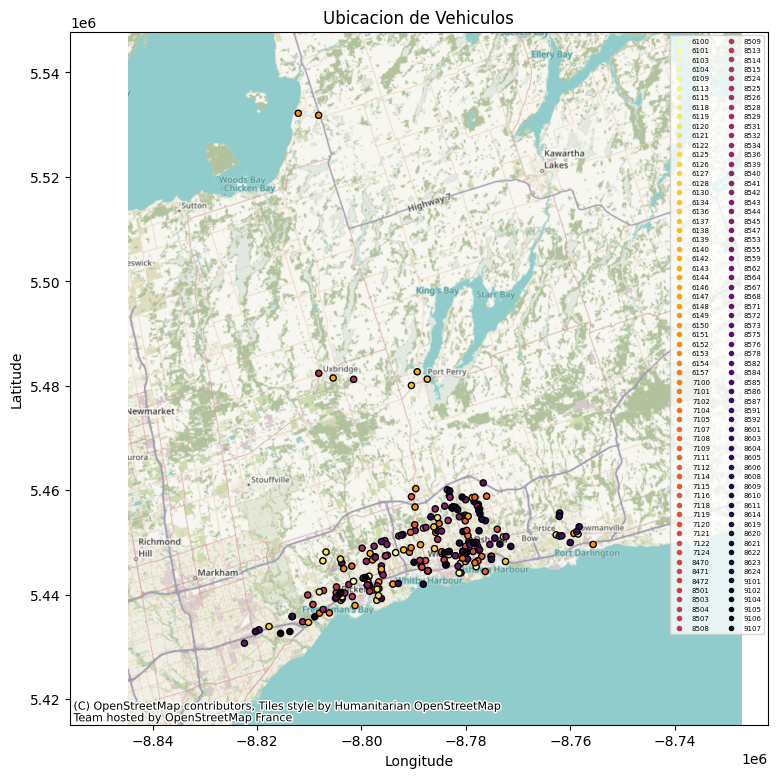

{'vehicles_with_connections': 0,
 'vehicles_with_one_pair': 0,
 'total_connections': 0}

In [66]:
# Load previous positions for comparison
try:
    with open(previous_path, 'r') as f:
        prev_geojson = json.load(f)
        prev_positions = []
        for feature in prev_geojson['features']:
            props = feature['properties']
            prev_positions.append({
                'vehicle_id': props.get('vehicle_id'),
                'latitude': feature['geometry']['coordinates'][1],
                'longitude': feature['geometry']['coordinates'][0]
            })
        prev_pos_df = pd.DataFrame(prev_positions)
except:
    prev_pos_df = pd.DataFrame()

utils.plot_map([veh_pos_df, prev_pos_df], "longitude", "latitude", 'vehicle_id', 'inferno_r', 'Ubicacion de Vehiculos')

## 6.5 - Mapa de Formas de Rutas y Paradas

2026-06-19 08:54:43,555 - _utils_ - INFO - Filtered to 8 shapes for route 905


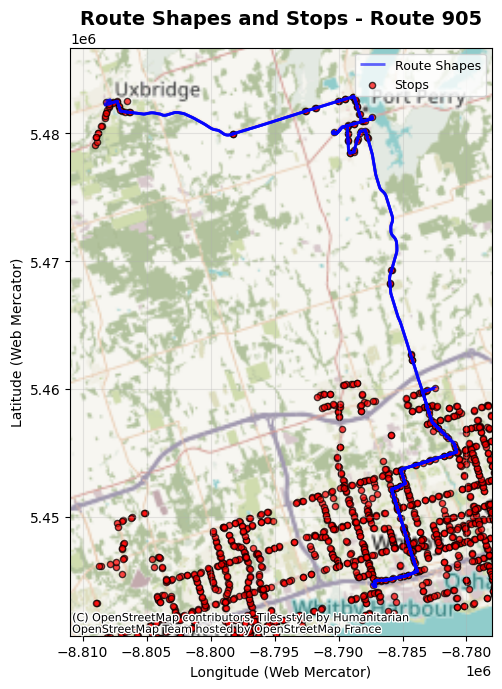

In [67]:
MAIN_ROUTE_ID = gtfs_rt_urls[city]['main_route_id']
# Plot route shapes and stops
# Load trips if not already loaded
if 'trips' not in locals():
    trips = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "trips.txt"))

# Load routes if not already loaded  
if 'routes' not in locals():
    routes = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "routes.txt"))

# Load stops if not already loaded
if 'stops' not in locals():
    stops = pd.read_csv(os.path.join(gtfs_static_dirs[city]["path"], "stops.txt"))

# Plot all routes or filter by main route
utils.plot_route_shapes_and_stops(
    shapes_df=shapes,
    stops_df=stops,
    route_id=MAIN_ROUTE_ID,  # Filter by main route
    trips_df=trips,
    routes_df=routes,
    title=f"Route Shapes and Stops - Route {MAIN_ROUTE_ID}",
    figsize=(10, 7)
)

## 7 - Métricas de Performance

In [68]:
# # On-Time Performance
# if not trip_updates_df.empty and not stop_times.empty:
#     otp_metrics = metrics.calculate_on_time_performance(trip_updates_df, stop_times, stops, on_time_threshold_minutes=2)
#     if otp_metrics:
#         print(f"OTP: {otp_metrics.get('otp_percentage', 0):.2f}%")
#         print(f"Average Delay: {otp_metrics.get('average_delay_minutes', 0):.2f} minutes")

In [63]:
# # Headway Analysis
# if not veh_pos_df.empty and not trips.empty:
#     headway_metrics = metrics.calculate_headways(veh_pos_df, trips, route_id=MAIN_ROUTE_ID)
#     if headway_metrics:
#         print(f"Average Headway: {headway_metrics.get('average_headway_minutes', 0):.2f} minutes")
#         print(f"Bunching Events: {headway_metrics.get('bunching_events', 0)}")

In [64]:
# # # Service Frequency
# if not veh_pos_df.empty and not trips.empty:
#     frequency_metrics = metrics.calculate_service_frequency(veh_pos_df, trips, time_window_minutes=60)
#     if frequency_metrics:
#         print(f"Overall Frequency: {frequency_metrics.get('overall_frequency_per_hour', 0):.2f} vehicles/hour")

In [ ]:
# Speed and Travel Time
if not position_history_df.empty:
    speed_metrics = metrics.calculate_speed_and_travel_time(position_history_df, shapes_df=shapes, trips_df=trips)
    if speed_metrics:
        print(f"Average Speed: {speed_metrics.get('average_speed_kmh', 0):.2f} km/h")
        print(f"Median Speed: {speed_metrics.get('median_speed_kmh', 0):.2f} km/h")

Average Speed: 19.16 km/h
Median Speed: 19.27 km/h


In [ ]:
# Spatial Coverage
if not veh_pos_df.empty and not routes.empty:
    coverage_metrics = metrics.calculate_spatial_coverage(veh_pos_df, routes, shapes_df=None, stops_df=stops)
    if coverage_metrics and 'route_coverage' in coverage_metrics:
        rc = coverage_metrics['route_coverage']
        print(f"Route Coverage: {rc.get('coverage_percentage', 0):.2f}%")

Route Coverage: 94.87%


In [ ]:
# ON_TIME_THRESHOLD_MINUTES = 5
# # Calculate On-Time Performance
# if not trip_updates_df.empty and not stop_times.empty:
#     otp_metrics = metrics.calculate_on_time_performance(
#         trip_updates_df,
#         stop_times,
#         stops,
#         on_time_threshold_minutes=ON_TIME_THRESHOLD_MINUTES
#     )
    
#     if otp_metrics:
#         logger.info("On-Time Performance Metrics:")
#         logger.info(f"  OTP Percentage: {otp_metrics.get('otp_percentage', 0):.2f}%")
#         logger.info(f"  Average Delay: {otp_metrics.get('average_delay_minutes', 0):.2f} minutes")
#         logger.info(f"  On-Time Stops: {otp_metrics.get('on_time_stops', 0)}/{otp_metrics.get('total_stops', 0)}")
        
#         display(pd.DataFrame([otp_metrics]).T.rename(columns={0: 'Value'}))
#     else:
#         logger.warning("Could not calculate OTP metrics")
# else:
#     logger.warning("Insufficient data for OTP calculation")

In [ ]:
# # Calculate Headway Analysis
# if not veh_pos_df.empty and not trips.empty:
#     headway_metrics = metrics.calculate_headways(
#         veh_pos_df,
#         trips,
#         route_id=MAIN_ROUTE_ID if MAIN_ROUTE_ID else None
#     )
    
#     if headway_metrics:
#         logger.info("Headway Metrics:")
#         logger.info(f"  Average Headway: {headway_metrics.get('average_headway_minutes', 0):.2f} minutes")
#         logger.info(f"  Bunching Events: {headway_metrics.get('bunching_events', 0)}")
#         logger.info(f"  Gap Events: {headway_metrics.get('gap_events', 0)}")
        
#         display(pd.DataFrame([headway_metrics]).T.rename(columns={0: 'Value'}))
#     else:
#         logger.warning("Could not calculate headway metrics")
# else:
#     logger.warning("Insufficient data for headway calculation")

In [ ]:
# SERVICE_FREQUENCY_WINDOW_MINUTES=60
# # Calculate Service Frequency
# if not veh_pos_df.empty and not trips.empty:
#     frequency_metrics = metrics.calculate_service_frequency(
#         veh_pos_df,
#         trips,
#         time_window_minutes=SERVICE_FREQUENCY_WINDOW_MINUTES
#     )
    
#     if frequency_metrics:
#         logger.info("Service Frequency Metrics:")
#         logger.info(f"  Overall Frequency: {frequency_metrics.get('overall_frequency_per_hour', 0):.2f} vehicles/hour")
#         logger.info(f"  Routes with Service: {frequency_metrics.get('total_routes_with_service', 0)}")
        
#         if 'frequency_by_route' in frequency_metrics:
#             freq_df = pd.DataFrame(frequency_metrics['frequency_by_route']).T
#             display(freq_df)
#     else:
#         logger.warning("Could not calculate frequency metrics")
# else:
#     logger.warning("Insufficient data for frequency calculation")

In [ ]:
# Calculate Speed and Travel Time Analysis
if not position_history_df.empty:
    speed_metrics = metrics.calculate_speed_and_travel_time(
        position_history_df,
        shapes_df=shapes if not shapes.empty else None,
        trips_df=trips if not trips.empty else None
    )
    
    if speed_metrics:
        logger.info("Speed and Travel Time Metrics:")
        logger.info(f"  Average Speed: {speed_metrics.get('average_speed_kmh', 0):.2f} km/h")
        logger.info(f"  Median Speed: {speed_metrics.get('median_speed_kmh', 0):.2f} km/h")
        logger.info(f"  Max Speed: {speed_metrics.get('max_speed_kmh', 0):.2f} km/h")
        
        display(pd.DataFrame([{k: v for k, v in speed_metrics.items() if k not in ['speed_by_vehicle', 'speed_by_route']}]).T.rename(columns={0: 'Value'}))
    else:
        logger.warning("Could not calculate speed metrics")
else:
    logger.warning("Insufficient position history for speed calculation")

2026-01-26 17:05:01,528 - __main__ - INFO - Speed and Travel Time Metrics:
2026-01-26 17:05:01,529 - __main__ - INFO -   Average Speed: 19.16 km/h
2026-01-26 17:05:01,530 - __main__ - INFO -   Median Speed: 19.27 km/h
2026-01-26 17:05:01,531 - __main__ - INFO -   Max Speed: 93.81 km/h


,Value
average_speed_mps,5.322561
average_speed_kmh,19.161220
median_speed_kmh,19.272329
max_speed_kmh,93.813158
min_speed_kmh,0.000000
speed_std_kmh,12.799993
average_travel_time_seconds,604.952385
total_measurements,275.000000


In [ ]:
# Calculate Spatial Coverage Metrics
if not veh_pos_df.empty and not routes.empty:
    coverage_metrics = metrics.calculate_spatial_coverage(
        veh_pos_df,
        routes,
        shapes_df= None,
        stops_df=stops if not stops.empty else None
    )
    
    if coverage_metrics:
        logger.info("Spatial Coverage Metrics:")
        if 'route_coverage' in coverage_metrics:
            rc = coverage_metrics['route_coverage']
            logger.info(f"  Route Coverage: {rc.get('coverage_percentage', 0):.2f}% ({rc.get('active_routes', 0)}/{rc.get('total_routes', 0)})")
        
        if 'vehicles_per_route' in coverage_metrics:
            logger.info(f"  Average Vehicles per Route: {coverage_metrics.get('average_vehicles_per_route', 0):.2f}")
        
        # Display as multi-index DataFrame
        coverage_df = utils.dict_to_multiindex_df(coverage_metrics)
        display(coverage_df)
        #display(pd.DataFrame([coverage_metrics]).T.rename(columns={0: 'Value'}))
    else:
        logger.warning("Could not calculate coverage metrics")
else:
    logger.warning("Insufficient data for coverage calculation")

2026-01-26 17:05:01,549 - __main__ - INFO - Spatial Coverage Metrics:
2026-01-26 17:05:01,550 - __main__ - INFO -   Route Coverage: 94.87% (37/39)
2026-01-26 17:05:01,551 - __main__ - INFO -   Average Vehicles per Route: 3.62


Value
route_coverage             active_routes                                                       37
                           total_routes                                                        39
                           coverage_percentage                                          94.871795
                           active_route_ids     [112, 900, 605, 917, 409, 410, 407, 901, 419, ...
stop_coverage              total_stops                                                       1909
                           note                 Distance-based coverage calculation requires s...
vehicles_per_route         101                                                                  1
                           112                                                                  3
                           118                                                                  1
                           121                                                                  3
                           211                                                                  1
                           216                                                                  6
                           224                                                                  2
                           227                                                                  4
                           301                                                                  1
                           302                                                                  7
                           306                                                                  1
                           315                                                                  1
                           319                                                                  2
                           392                                                                  1
                           403                                                                  3
                           405                                                                  3
                           407                                                                  3
                           409                                                                  3
                           410                                                                  4
                           419                                                                  1
                           421                                                                  4
                           423                                                                  1
                           502                                                                  3
                           505                                                                  2
                           507                                                                  2
                           605                                                                  1
                           618                                                                  2
                           801                                                                  1
                           900                                                                 12
                           901                                                                  7
                           902                                                                  6
                           905                                                                  6
                           915                                                                  6
                           916                                                                  8
                           917                                            

# Section 7: Summary and Data Quality Report

In [ ]:
# Generate summary report
logger.info("=" * 60)
logger.info("DATA COLLECTION SUMMARY")
logger.info("=" * 60)
logger.info(f"Capture Timestamp: {capture_timestamp.isoformat()}")
logger.info(f"Vehicle Positions: {len(veh_pos_df)}")
logger.info(f"Trip Updates: {len(trip_updates_df)}")
logger.info(f"Position History Records: {len(position_history_df)}")
logger.info(f"Unique Vehicles Tracked: {len(position_history)}")

# Data quality checks
if not veh_pos_df.empty:
    missing_coords = veh_pos_df[['latitude', 'longitude']].isnull().sum()
    logger.info(f"Missing Coordinates: {missing_coords.sum()}")
    
    if 'route_id' in veh_pos_df.columns:
        routes_with_vehicles = veh_pos_df['route_id'].nunique()
        logger.info(f"Routes with Active Vehicles: {routes_with_vehicles}")

logger.info("=" * 60)

2026-01-26 17:05:01,574 - __main__ - INFO - ============================================================
2026-01-26 17:05:01,576 - __main__ - INFO - DATA COLLECTION SUMMARY
2026-01-26 17:05:01,580 - __main__ - INFO - ============================================================
2026-01-26 17:05:01,581 - __main__ - INFO - Capture Timestamp: 2026-01-26T17:04:39.713762
2026-01-26 17:05:01,583 - __main__ - INFO - Vehicle Positions: 134
2026-01-26 17:05:01,584 - __main__ - INFO - Trip Updates: 8705
2026-01-26 17:05:01,585 - __main__ - INFO - Position History Records: 421
2026-01-26 17:05:01,586 - __main__ - INFO - Unique Vehicles Tracked: 143
2026-01-26 17:05:01,588 - __main__ - INFO - Missing Coordinates: 0
2026-01-26 17:05:01,590 - __main__ - INFO - Routes with Active Vehicles: 37
2026-01-26 17:05:01,591 - __main__ - INFO - ============================================================
